In [1]:
import pandas as pd
import sys
import os
import numpy as np

# Get the parent directory of the notebooks folder
notebook_dir = os.path.dirname(os.path.abspath('__file__'))
parent_dir = os.path.dirname(notebook_dir)
sys.path.insert(0, parent_dir)

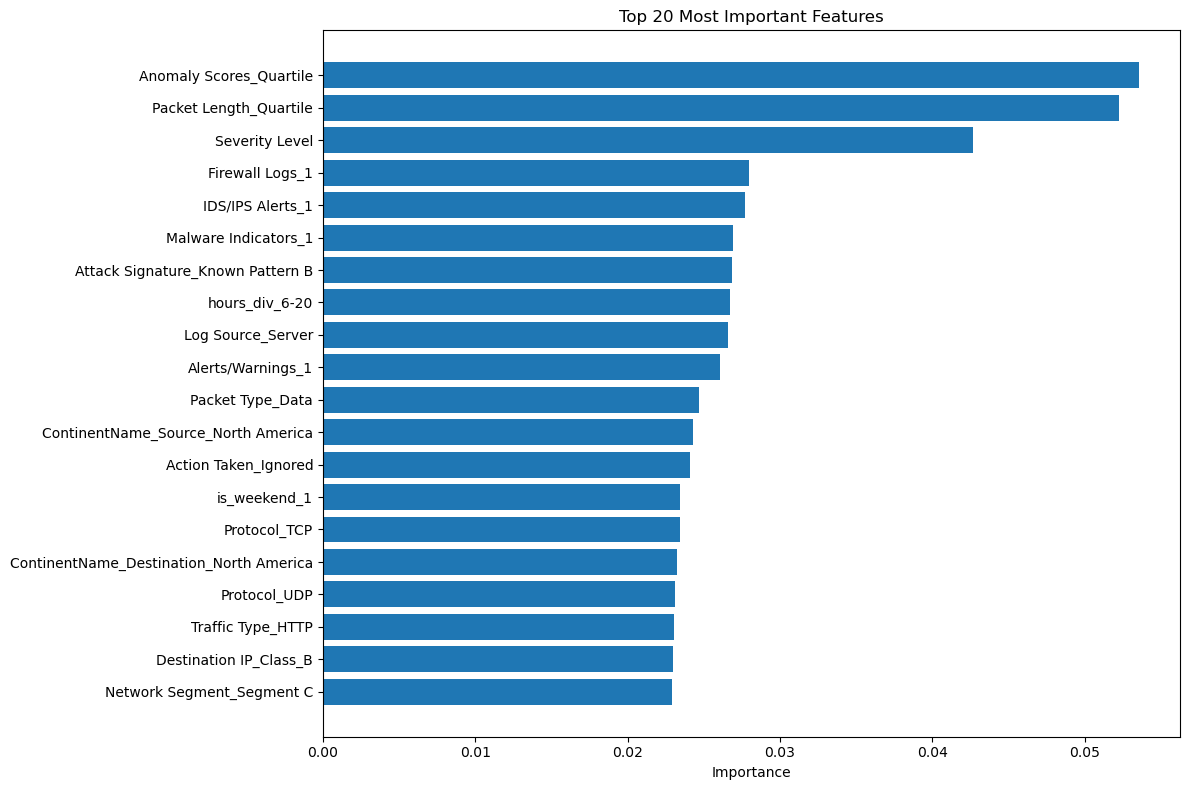

Top 10 Most Important Features:
                             feature  importance
37           Anomaly Scores_Quartile    0.053577
36            Packet Length_Quartile    0.052260
10                    Severity Level    0.042674
13                   Firewall Logs_1    0.027965
14                  IDS/IPS Alerts_1    0.027731
5               Malware Indicators_1    0.026892
7   Attack Signature_Known Pattern B    0.026870
17                    hours_div_6-20    0.026703
15                 Log Source_Server    0.026612
6                  Alerts/Warnings_1    0.026074

Top 10 Features by Mutual Information:
                                    feature  mi_score
10                           Severity Level  0.007509
27                        Source IP_Class_B  0.006875
33                      Proxy_Class_noProxy  0.006520
47                           Device_type_PC  0.006355
14                         IDS/IPS Alerts_1  0.006236
49                      Device_type_Unknown  0.005183
8          

In [ ]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, mutual_info_classif
import matplotlib.pyplot as plt

In [ ]:
# Load dataset (already encoded)
df = pd.read_csv('../data/processed_data/cybersecurity_attacks_dataset1_finalfeatures.csv')

In [ ]:
# Separate features and target
X = df.drop('Attack Type', axis=1)
y = df['Attack Type']

In [ ]:
# 1. Check feature importance with Random Forest
rf_temp = RandomForestClassifier(n_estimators=100, random_state=0)
rf_temp.fit(X, y)

In [ ]:
# Plot feature importances
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_temp.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(12, 8))
plt.barh(feature_importance['feature'][:20], feature_importance['importance'][:20])
plt.xlabel('Importance')
plt.title('Top 20 Most Important Features')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../data/results/feature_importance.png')
plt.show()

print("Top 10 Most Important Features:")
print(feature_importance.head(10))

In [ ]:
# 2. Use Mutual Information to identify features with predictive power
mi_scores = mutual_info_classif(X, y, random_state=0)
mi_df = pd.DataFrame({
    'feature': X.columns,
    'mi_score': mi_scores
}).sort_values('mi_score', ascending=False)

print("\nTop 10 Features by Mutual Information:")
print(mi_df.head(10))

In [ ]:
# 3. Create interaction features for top features
top_features = feature_importance['feature'][:10].tolist()
print(top_features)

In [ ]:
# Example: Create interaction between top 2 features
df[f'{top_features[0]}_x_{top_features[1]}'] = df[top_features[0]] * df[top_features[1]]

In [7]:
# Identify low-importance features to potentially drop
low_importance_threshold = 0.001 # should we adjust?
low_importance_features = feature_importance[feature_importance['importance'] < low_importance_threshold]
print(f"\n{len(low_importance_features)} features with importance < {low_importance_threshold}")
print("Consider dropping these features to simplify the model.")


0 features with importance < 0.001
Consider dropping these features to simplify the model.
